<a href="https://colab.research.google.com/github/dhan4567/Machine_Learning_Projects/blob/main/predict_Restaurant_Ratings_Cognifyz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import** Requied Libraries**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,r2_score

Load Dataset

In [ ]:
df = pd.read_csv("/content/Dataset .csv")
print(df.head())
print(df.shape)

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

Check Missing **Values**

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [ ]:
#for numerical Column

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
  df[col].fillna(df[col].median(),inplace=True)

/tmp/ipykernel_2767/3536850428.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [ ]:
#for categorical column

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
  df[col].fillna(df[col].mode()[0],inplace=True)

/tmp/ipykernel_2767/1215658320.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


Encode Categorical **Variables**

In [ ]:
le= LabelEncoder()

for col in categorical_cols:
  df[col]=le.fit_transform(df[col])


In [ ]:
print(df.head())

   Restaurant ID  Restaurant Name  Country Code  City  Address  Locality  \
0        6317637             3748           162    73     8685       171   
1        6304287             3172           162    73     6055       593   
2        6300002             2896           162    75     4684       308   
3        6318506             4707           162    75     8690       862   
4        6314302             5523           162    75     8689       862   

   Locality Verbose   Longitude   Latitude  Cuisines  ...  Currency  \
0               172  121.027535  14.565443       920  ...         0   
1               601  121.014101  14.553708      1111  ...         0   
2               314  121.056831  14.581404      1671  ...         0   
3               875  121.056475  14.585318      1126  ...         0   
4               875  121.057508  14.584450      1122  ...         0   

   Has Table booking  Has Online delivery  Is delivering now  \
0                  1                    0           

Define Features And **Target**

In [ ]:
#Target
y= df["Aggregate rating"]

In [ ]:
#Feature
x=df.drop("Aggregate rating", axis=1)

Split The Data For Training And **Testing**

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Train Linear Regression **Model**

In [ ]:
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)

LinearRegression()

In [ ]:
lr_pred= lr_model.predict(x_test)

Evaluate Linear **Regression**

In [ ]:
#Mean Squared Error

lr_mse = mean_squared_error(y_test,lr_pred)

In [ ]:
#R Score

lr_r2= r2_score(y_test,lr_pred)

In [ ]:
print("Linear Regression Result")
print("MSE:",lr_mse)
print("R2 Score",lr_r2)

Linear Regression Result
MSE: 1.2186925059460247
R2 Score 0.4645719905617005


Train-Decision Tree **Regressor**

In [ ]:
dt_model= DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)
dt_model.fit(x_train,y_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
dt_pred= dt_model.predict(x_test)

Evaluate Decision **Tree**

In [ ]:
dt_mse = mean_squared_error(y_test,dt_pred)

dt_r2 = r2_score(y_test,dt_pred)

print("Decision Tree Result")
print("MSE:",dt_mse)
print("R2 Score",dt_r2)

Decision Tree Result
MSE: 0.02995872459230026
R2 Score 0.9868377460306825


Compare **Models**

In [ ]:
print ("Model Comparison")
print("Linear Regression MSE:",lr_mse)
print("Linear Regression R2 Score",lr_r2)
print("Decision Tree MSE:",dt_mse)
print("Decision Tree R2 Score",dt_r2)

Model Comparison
Linear Regression MSE: 1.2186925059460247
Linear Regression R2 Score 0.4645719905617005
Decision Tree MSE: 0.02995872459230026
Decision Tree R2 Score 0.9868377460306825


Feature Importance **Analysis**

In [ ]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': dt_model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
    )

print(importance.head(10))

                 Feature  Importance
19                 Votes    0.909243
17          Rating color    0.083075
18           Rating text    0.007499
0          Restaurant ID    0.000096
8               Latitude    0.000026
10  Average Cost for two    0.000023
12     Has Table booking    0.000021
7              Longitude    0.000017
3                   City    0.000000
2           Country Code    0.000000


**Visualization**

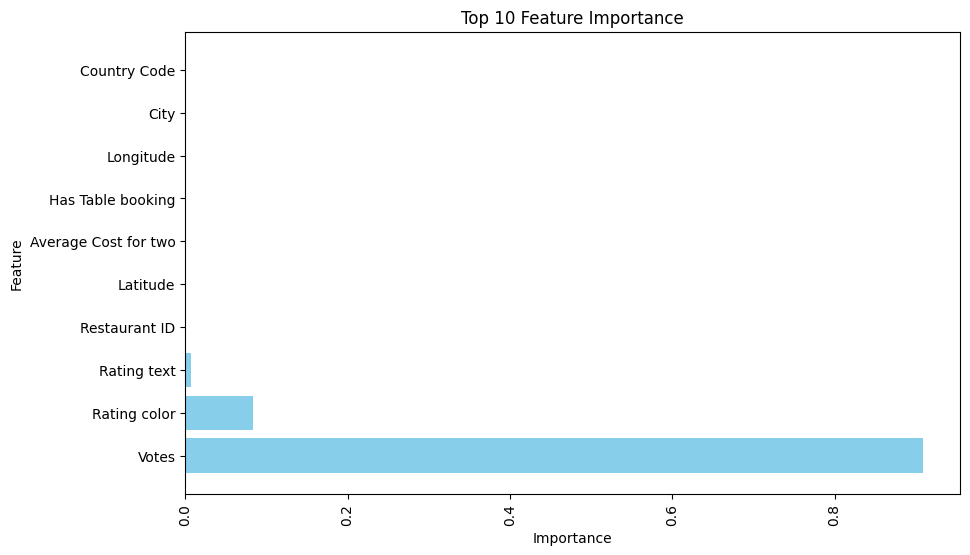

In [ ]:
import matplotlib.pyplot as plt

top_features = importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'],top_features['Importance'],color='skyblue')
plt.xticks(rotation=90)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance')
plt.show()